In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # points to src/systematic_trading

from data.minute_data_loader import get_minute_quotes
import datetime as dt
import pandas as pd


traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDZAR",
    "USDPLN",
    "EURPLN",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "USDSGD",
    "USDMXN",
    "NZDUSD",
]

marketdata_instruments = traded_instruments # + ["UDXUSD", "XAUUSD"]

minute_dict = get_minute_quotes(
    marketdata_instruments,
    dt.date(2023, 1, 2),
    dt.date(2026, 1, 31),
)

In [71]:
import importlib
import strategy.factor_mean_reversion_strategy as fmrs

importlib.reload(fmrs)
from strategy.factor_mean_reversion_strategy import FactorMeanReversionStrategy

strategy = FactorMeanReversionStrategy(
    instruments=traded_instruments,
    close_price_dict=minute_dict,
    hyper_param_dict={
        "zs_entry_threshold": 3,
        "zs_exit_threshold": -0.5,
        "spread_entry_multiplier": 5,
        "residual_rolling_lookback": pd.Timedelta(minutes=20),
    },
)

In [2]:
from data.minute_data_loader import get_minute_bars
import datetime as dt
import pandas as pd

instruments = ["AUDUSD", "EURUSD", "GBPUSD", "USDJPY", "USDCHF", "USDCAD", "USDZAR", "USDMXN", "NZDUSD"]

tmp = get_minute_bars(
    instruments,
    dt.date(2025, 9, 2),
    dt.date(2026, 1, 31),
)
for ccy_pair,df in tmp.items():
    df = df[~df.index.duplicated(keep='last')]
    df['bid'] = df['close']
    df['ask'] = df['close']
    df['mid'] = df['close']
    df = df.drop(columns=['open', 'high', 'low', 'close'])
    tmp[ccy_pair] = df
minute_dict = tmp

In [72]:
from trading.aggressive_trader import AggressiveTrader

signals = strategy.generate_signals2()
trader = AggressiveTrader(traded_instruments, minute_dict, signals)

In [75]:
factor_pca_rolling_lookback = pd.Timedelta(days=60)
spread_rolling_lookback = pd.Timedelta(minutes=30)

# Mid returns
rets = strategy.compute_mid_returns()

# USD factor and loadings
factor = strategy.compute_principal_factor(
    rets,
    method="rolling_pca",
    window=factor_pca_rolling_lookback,
    return_bucket_length=pd.Timedelta(hours=6),
    calc_freq=pd.Timedelta(days=7),
    n_components=2,
)
beta, residuals = strategy.rolling_regression(rets['AUDUSD'], factor)

<Axes: >

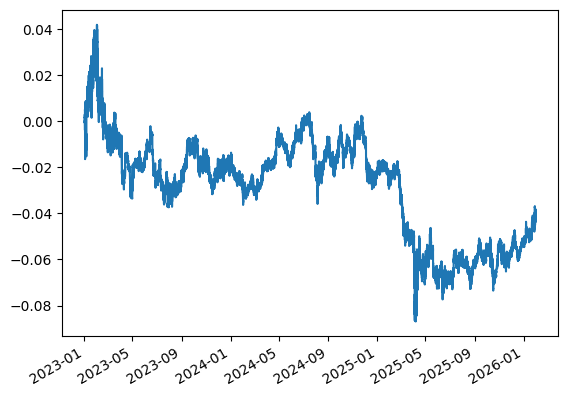

In [63]:
residuals.cumsum().plot()

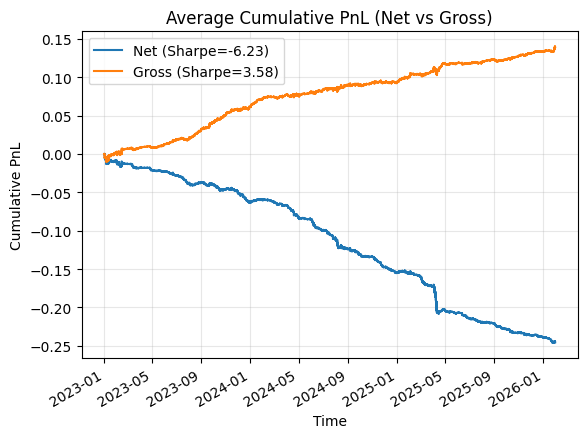

In [73]:
import numpy as np

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * 24 * 60) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * 24 * 60) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [74]:
from analytics.performance_report import PerformanceReport

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
AUDUSD,-0.877033,1.147756,44.37833,-0.177301,-0.043145,-0.000003,0.000004,0 days 00:07:35.382148,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
EURUSD,-0.118452,0.732417,44.428064,-0.077918,-0.015824,-0.0,0.000002,0 days 00:07:35.406166,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
GBPUSD,-0.711598,0.828282,44.373002,-0.099983,-0.012045,-0.000001,0.000002,0 days 00:07:35.016262,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
EURGBP,-1.964735,1.220635,3.811723,-0.14359,-0.007324,-0.000031,0.000019,0 days 00:28:32.041006,0 days 00:22:00,0 days 00:11:00,0 days 00:53:00
EURJPY,-1.026735,0.112367,3.188277,-0.233142,-0.015404,-0.000041,0.000004,0 days 00:28:24.367688,0 days 00:22:00,0 days 00:12:00,0 days 00:53:00
USDJPY,-0.622929,0.123818,44.387211,-0.149309,-0.018688,-0.000002,0.0,0 days 00:07:34.996106,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
USDCHF,-1.760297,0.442372,44.403197,-0.240088,-0.020551,-0.000005,0.000001,0 days 00:07:35.745850,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
EURCHF,-0.828644,1.978878,3.843694,-0.092192,-0.010733,-0.000017,0.000043,0 days 00:27:13.752310,0 days 00:21:00,0 days 00:11:00,0 days 00:51:00
USDCAD,-1.613978,0.704894,44.371226,-0.145787,-0.012891,-0.000003,0.000001,0 days 00:07:35.235586,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00
USDZAR,-3.59846,1.484681,44.512,-0.655619,-0.019766,-0.000013,0.000005,0 days 00:07:36.283570,0 days 00:04:00,0 days 00:01:00,0 days 00:19:00


In [42]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "USDPLN"
date_range = (dt.date(2025, 9, 2), dt.date(2025, 9, 30))
close_price_df = minute_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)

In [2]:
import pandas as pd
from analytics.hyperparam_optimizer import optimize_factor_mean_reversion_hyperparams

param_grid = {
    "zs_entry_threshold": [1.0, 2.0, 3.0],
    "zs_exit_threshold": [-1.0, -0.5, 0.0, 0.5],
    "spread_entry_multiplier": [5.0, 10.0, 15.0, 20.0],
    "residual_rolling_lookback": [
        pd.Timedelta("10min"),
        pd.Timedelta("20min"),
        pd.Timedelta("30min"),
        #pd.Timedelta("45min"),
        pd.Timedelta("1h"),
        pd.Timedelta("2h"),
        #pd.Timedelta("3h"),
        pd.Timedelta("4h"),
        #pd.Timedelta("5h"),
    ],
}

result = optimize_factor_mean_reversion_hyperparams(
    instruments=traded_instruments,
    close_price_dict=minute_dict,
    param_grid=param_grid,
    log_path="hyperparam_trials.csv",
    checkpoint_every=5,
)

print(result.best_sharpe_by_pair)      # best Sharpe + params per pair
print(result.elapsed_seconds)           # timer harness total runtime
print(result.total_trials, result.log_path)


        best_sharpe_net                                        best_params
AUDUSD         1.183647  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
EURCHF         1.273392  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURGBP         1.171359  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
EURJPY         1.624003  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURNOK         1.507984  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURPLN         1.602117  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
EURSEK         1.480519  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
EURUSD         1.291299  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
GBPUSD         0.248342  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
NZDUSD         0.439078  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
USDCAD         1.279176  {'zs_entry_threshold': 2.0, 'zs_exit_threshold...
USDCHF         0.059631  {'zs_entry_threshold': 2.0, 'zs_exit_threshold...
USDJPY         2.179727  

In [24]:
tmp = pd.read_csv('hyperparam_trials.csv')

In [ ]:
x = tmp[
    (tmp["AUDUSD__AvgTradesPerDay"] > 1)
    & (tmp["AUDUSD__AvgTradesPerDay"] < 10)
    & (tmp["AUDUSD__Sharpe_Net"] > 0)
]
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]

["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + ["AUDUSD__" + a for a in names]

['param__zs_entry_threshold',
 'param__zs_exit_threshold',
 'param__spread_entry_multiplier',
 'param__residual_rolling_lookback',
 'AUDUSD__Sharpe_Net',
 'AUDUSD__Sharpe_Gross',
 'AUDUSD__AvgTradesPerDay',
 'AUDUSD__MaxDrawdown',
 'AUDUSD__WorstDayPnL',
 'AUDUSD__AvgNetPnLPerTrade',
 'AUDUSD__AvgGrossPnLPerTrade',
 'AUDUSD__AvgPosDur',
 'AUDUSD__MedPosDur',
 'AUDUSD__Q10PosDur',
 'AUDUSD__Q90PosDur']

In [69]:
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]
r = []

for instrument in traded_instruments:
    instrument_names = [instrument + "__" + a for a in names]
    x = tmp[(tmp[instrument + '__AvgTradesPerDay']>1) &(tmp[instrument + '__Sharpe_Net']>0.3)]
    x = x[["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + instrument_names]
    x = x.rename(columns=dict(zip(instrument_names, names)))
    x["sym"] = instrument
    
    r.append(x)